# ProdiRank data intake and cleanup notebook

This notebook cleans Brian's compound/SMILES files and CCK-8 plate-reader files into analysis-ready tables.

Main outputs:

- `outputs/compound_manifest_clean.csv`
- `outputs/cck8_raw_well_values.csv`
- `outputs/cck8_summary_tidy.csv`
- `outputs/ec50_summary.csv`
- `outputs/public_obatoclax_gene_summary.csv`
- `outputs/figures/*.png`

The notebook is intentionally conservative. It does **not** assume H11, D12, or 2H11 are mapped to BW-II IDs until Brian confirms the mapping.


In [1]:
# ---- 0. Setup ----
from pathlib import Path
import re
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Edit this if your local/Box folder uses a different path.
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

# Input files. Keep names exactly as in Box/local folder, or edit here.
INPUT_FILES = {
    "smiles": DATA_DIR / "Unnatural prodigionsin_Smiles.xlsx",
    "bwii_activity": DATA_DIR / "BWII Compounds.xlsx",
    "cck_activity": DATA_DIR / "CCK BW1 H11 D12 2H11.xlsx",
    "obatoclax_summary": DATA_DIR / "grant_summary_table.csv",
}

for label, path in INPUT_FILES.items():
    print(f"{label:20s}", "FOUND" if path.exists() else "MISSING", path)


smiles               FOUND /mnt/data/notebook_test/Unnatural prodigionsin_Smiles.xlsx
bwii_activity        FOUND /mnt/data/notebook_test/BWII Compounds.xlsx
cck_activity         FOUND /mnt/data/notebook_test/CCK BW1 H11 D12 2H11.xlsx
obatoclax_summary    FOUND /mnt/data/notebook_test/grant_summary_table.csv


In [2]:
# ---- 1. Helper functions ----

def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

# This is a permissive SMILES detector. RDKit validation happens later if RDKit is installed.
SMILES_CHARS = re.compile(r"^[A-Za-z0-9@+\-\[\]\(\)=#$\\/%.:]+$")
ID_PATTERN = re.compile(r"\b(BW[- ]?II[- ]?\d+|BW[- ]?I[- ]?\d+|H11|D12|2H11|JP.*?Cmpd\.?\s*\d+|Compound\s*\d+|Cmpd\.?\s*\d+)\b", re.I)

NOTE_WORDS = ["confirmed", "nmr", "ms", "lc-ms", "lcms", "made", "tested", "proposed", "compound", "analog"]

def looks_like_smiles(text):
    text = safe_str(text)
    if ID_PATTERN.search(text):
        return False
    if len(text) < 8:
        return False
    if " " in text:
        return False
    if not SMILES_CHARS.match(text):
        return False
    # Most entries here contain aromatic/hetero atoms and ring numbers.
    atom_like = any(ch in text for ch in list("CNOSPFIBrcnospcl"))
    ring_like = any(ch.isdigit() for ch in text)
    return atom_like and ring_like


def normalize_compound_id(text):
    text = safe_str(text)
    if not text:
        return ""
    text = text.replace("–", "-").replace("—", "-")
    text = re.sub(r"\s+", " ", text)
    # Standardize BW IDs.
    text = re.sub(r"BW\s*[- ]\s*II\s*[- ]\s*(\d+)", r"BW-II-\1", text, flags=re.I)
    text = re.sub(r"BW\s*[- ]\s*I\s*[- ]\s*(\d+)", r"BW-I-\1", text, flags=re.I)
    # Standardize JP term-paper references.
    m = re.search(r"Cmpd\.?\s*(\d+)", text, flags=re.I)
    if "JP" in text.upper() and m:
        return f"JP-Cmpd-{m.group(1)}"
    if re.match(r"Compound\s*\d+", text, flags=re.I):
        return "Compound-" + re.search(r"\d+", text).group(0)
    return text


def try_parse_excel_date(x):
    if pd.isna(x):
        return pd.NaT
    if isinstance(x, pd.Timestamp):
        return x
    # openpyxl/pandas often already returns datetime for Excel dates.
    try:
        return pd.to_datetime(x)
    except Exception:
        return pd.NaT


## 2. Clean Brian's compound/SMILES list

The SMILES workbook is currently a vertical note-style sheet rather than a database. This parser treats a SMILES line plus the nearest following compound ID line as one compound record. Notes such as `confirmed by MS` and `1HNMR` are kept as provenance.


In [3]:
# ---- 2. Compound manifest parser ----

def parse_smiles_workbook(path):
    df = pd.read_excel(path, header=None, dtype=object)
    values = [safe_str(v) for v in df.iloc[:, 0].tolist()]
    records = []
    section = None
    proposed_counter = 1

    i = 0
    while i < len(values):
        text = values[i]
        if not text:
            i += 1
            continue
        if not looks_like_smiles(text):
            # Treat long non-SMILES text as a section label.
            if len(text) > 10:
                section = text
            i += 1
            continue

        smiles_raw = text
        compound_id = ""
        notes = []
        # Look ahead until next SMILES or up to 8 rows.
        j = i + 1
        while j < len(values) and j <= i + 8:
            nxt = values[j]
            if looks_like_smiles(nxt):
                break
            if nxt:
                if ID_PATTERN.search(nxt) and not compound_id:
                    compound_id = normalize_compound_id(nxt)
                else:
                    notes.append(nxt)
            j += 1

        if not compound_id:
            if section and "proposed" in section.lower():
                compound_id = f"Proposed-benzothiazole-{proposed_counter:03d}"
                proposed_counter += 1
            else:
                compound_id = f"Unlabeled-{len(records)+1:03d}"

        records.append({
            "compound_id": compound_id,
            "paper_id": compound_id if compound_id.startswith("JP-Cmpd") else "",
            "source_section": section,
            "smiles_raw": smiles_raw,
            "notes_raw": "; ".join(notes),
            "source_file": Path(path).name,
            "source_row_excel_1based": i + 1,
            "needs_manual_review": compound_id.startswith("Unlabeled") or compound_id.startswith("Proposed"),
        })
        i = max(j, i + 1)

    return pd.DataFrame(records)

compound_manifest = parse_smiles_workbook(INPUT_FILES["smiles"])
compound_manifest


,compound_id,paper_id,source_section,smiles_raw,notes_raw,source_file,source_row_excel_1based,needs_manual_review
0,BW-II-1,,Compounds made and tested by UAMS,COC1=C(/C=C2N=C(C3=CC=CN3)C=C\2OC)NC(C4=CC=CN4...,confirmed by MS,Unnatural prodigionsin_Smiles.xlsx,2,False
1,BW-II-103,,Compounds made and tested by UAMS,C1(C2=NC3=C(C=CC=C3)S2)=CC=CN1,1HNMR,Unnatural prodigionsin_Smiles.xlsx,13,False
2,BW-II-106,,Compounds made and tested by UAMS,ClC1=CC2=C(C=C1)SC(C3=CC=CN3)=N2,,Unnatural prodigionsin_Smiles.xlsx,21,False
3,BW-II-110,,Compounds made and tested by UAMS,COC(C=C1)=CC2=C1N=C(S2)C3=CC=CN3,,Unnatural prodigionsin_Smiles.xlsx,29,False
4,Proposed-benzothiazole-001,,Proposed Unnatural prodigiosin analogs as anti...,COC1=C(C2=NC3=C(C=CC=C3)S2)NC(C4=CC=CN4)=C1,,Unnatural prodigionsin_Smiles.xlsx,40,True
5,JP-Cmpd-6,JP-Cmpd-6,Proposed Unnatural prodigiosin analogs as anti...,COC1=CC(C(S2)=NC3=C2C=CC=C3)=N/C1=C\C4=CC=CN4,,Unnatural prodigionsin_Smiles.xlsx,48,False
6,JP-Cmpd-10,JP-Cmpd-10,Proposed Unnatural prodigiosin analogs as anti...,COC1=CC(C2=CC=CN2)=N/C1=C\C3=NC(C=CC=C4)=C4S3,,Unnatural prodigionsin_Smiles.xlsx,55,False
7,Proposed-benzothiazole-002,,Proposed Unnatural prodigiosin analogs as anti...,CCCC(C=C1)=CC2=C1N=C(S2)C(NC(C3=CC=CN3)=C4)=C4OC,,Unnatural prodigionsin_Smiles.xlsx,66,True
8,Proposed-benzothiazole-003,,Proposed Unnatural prodigiosin analogs as anti...,COC1=C(C2=NC3=C(C(C)=CC=C3C)S2)NC(C4=CC=CN4)=C1,,Unnatural prodigionsin_Smiles.xlsx,76,True
9,Proposed-benzothiazole-004,,Proposed Unnatural prodigiosin analogs as anti...,COC1=C(C2=NC3=C(C=C(OC)C=C3)S2)NC(C4=CC=CN4)=C1,,Unnatural prodigionsin_Smiles.xlsx,86,True


In [4]:
# ---- 2b. Optional RDKit validation and descriptors ----
# If RDKit is not installed, the notebook still runs and leaves descriptor fields blank.
try:
    from rdkit import Chem
    from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
    from rdkit.Chem.MolStandardize import rdMolStandardize
    RDKIT_AVAILABLE = True
except Exception as e:
    print("RDKit not available. Install with: conda install -c conda-forge rdkit")
    print("Proceeding without SMILES standardization/descriptors.")
    RDKIT_AVAILABLE = False


def standardize_smiles(smiles):
    if not RDKIT_AVAILABLE:
        return "", False, "RDKit unavailable"
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return "", False, "MolFromSmiles failed"
        # Cleanup and fragment parent help remove salts/solvents if present.
        mol = rdMolStandardize.Cleanup(mol)
        mol = rdMolStandardize.FragmentParent(mol)
        smi = Chem.MolToSmiles(mol, canonical=True)
        return smi, True, ""
    except Exception as e:
        return "", False, str(e)


def calc_descriptors(smiles_clean):
    fields = {
        "mol_wt_rdkit": np.nan,
        "logp_rdkit": np.nan,
        "tpsa": np.nan,
        "hbd": np.nan,
        "hba": np.nan,
        "rotatable_bonds": np.nan,
        "aromatic_rings": np.nan,
        "heavy_atoms": np.nan,
    }
    if not RDKIT_AVAILABLE or not smiles_clean:
        return fields
    mol = Chem.MolFromSmiles(smiles_clean)
    if mol is None:
        return fields
    fields.update({
        "mol_wt_rdkit": Descriptors.MolWt(mol),
        "logp_rdkit": Crippen.MolLogP(mol),
        "tpsa": rdMolDescriptors.CalcTPSA(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "rotatable_bonds": Lipinski.NumRotatableBonds(mol),
        "aromatic_rings": Lipinski.NumAromaticRings(mol),
        "heavy_atoms": mol.GetNumHeavyAtoms(),
    })
    return fields

std_rows = []
for smi in compound_manifest["smiles_raw"]:
    clean, valid, err = standardize_smiles(smi)
    std_rows.append({"smiles_clean": clean, "smiles_valid": valid, "smiles_error": err})
std_df = pd.DataFrame(std_rows)
compound_manifest = pd.concat([compound_manifest, std_df], axis=1)

desc = pd.DataFrame([calc_descriptors(s) for s in compound_manifest["smiles_clean"]])
compound_manifest = pd.concat([compound_manifest, desc], axis=1)

compound_manifest.to_csv(OUTPUT_DIR / "compound_manifest_clean.csv", index=False)
compound_manifest.to_excel(OUTPUT_DIR / "compound_manifest_clean.xlsx", index=False)
compound_manifest


[16:05:15] Initializing MetalDisconnector
[16:05:15] Running MetalDisconnector
[16:05:15] Initializing Normalizer
[16:05:15] Running Normalizer
[16:05:15] Initializing MetalDisconnector
[16:05:15] Running MetalDisconnector
[16:05:15] Initializing Normalizer
[16:05:15] Running Normalizer
[16:05:15] Running LargestFragmentChooser
[16:05:15] Initializing MetalDisconnector
[16:05:15] Running MetalDisconnector
[16:05:15] Initializing Normalizer
[16:05:15] Running Normalizer
[16:05:15] Initializing MetalDisconnector
[16:05:15] Running MetalDisconnector
[16:05:15] Initializing Normalizer
[16:05:15] Running Normalizer
[16:05:15] Running LargestFragmentChooser
[16:05:15] Initializing MetalDisconnector
[16:05:15] Running MetalDisconnector
[16:05:15] Initializing Normalizer
[16:05:15] Running Normalizer
[16:05:15] Initializing MetalDisconnector
[16:05:15] Running MetalDisconnector
[16:05:15] Initializing Normalizer
[16:05:15] Running Normalizer
[16:05:15] Running LargestFragmentChooser
[16:05:15]

,compound_id,paper_id,source_section,smiles_raw,notes_raw,source_file,source_row_excel_1based,needs_manual_review,smiles_clean,smiles_valid,smiles_error,mol_wt_rdkit,logp_rdkit,tpsa,hbd,hba,rotatable_bonds,aromatic_rings,heavy_atoms
0,BW-II-1,,Compounds made and tested by UAMS,COC1=C(/C=C2N=C(C3=CC=CN3)C=C\2OC)NC(C4=CC=CN4...,confirmed by MS,Unnatural prodigionsin_Smiles.xlsx,2,False,COC1=CC(c2ccc[nH]2)=N/C1=C\c1[nH]c(-c2ccc[nH]2...,True,,334.379,3.72060,78.19,3,3,5,3,25
1,BW-II-103,,Compounds made and tested by UAMS,C1(C2=NC3=C(C=CC=C3)S2)=CC=CN1,1HNMR,Unnatural prodigionsin_Smiles.xlsx,13,False,c1c[nH]c(-c2nc3ccccc3s2)c1,True,,200.266,3.29140,28.68,1,2,1,3,14
2,BW-II-106,,Compounds made and tested by UAMS,ClC1=CC2=C(C=C1)SC(C3=CC=CN3)=N2,,Unnatural prodigionsin_Smiles.xlsx,21,False,Clc1ccc2sc(-c3ccc[nH]3)nc2c1,True,,234.711,3.94480,28.68,1,2,1,3,15
3,BW-II-110,,Compounds made and tested by UAMS,COC(C=C1)=CC2=C1N=C(S2)C3=CC=CN3,,Unnatural prodigionsin_Smiles.xlsx,29,False,COc1ccc2nc(-c3ccc[nH]3)sc2c1,True,,230.292,3.30000,37.91,1,3,2,3,16
4,Proposed-benzothiazole-001,,Proposed Unnatural prodigiosin analogs as anti...,COC1=C(C2=NC3=C(C=CC=C3)S2)NC(C4=CC=CN4)=C1,,Unnatural prodigionsin_Smiles.xlsx,40,True,COc1cc(-c2ccc[nH]2)[nH]c1-c1nc2ccccc2s1,True,,295.367,4.29510,53.70,2,3,3,4,21
5,JP-Cmpd-6,JP-Cmpd-6,Proposed Unnatural prodigiosin analogs as anti...,COC1=CC(C(S2)=NC3=C2C=CC=C3)=N/C1=C\C4=CC=CN4,,Unnatural prodigionsin_Smiles.xlsx,48,False,COC1=CC(c2nc3ccccc3s2)=N/C1=C\c1ccc[nH]1,True,,307.378,3.99850,50.27,1,4,3,3,22
6,JP-Cmpd-10,JP-Cmpd-10,Proposed Unnatural prodigiosin analogs as anti...,COC1=CC(C2=CC=CN2)=N/C1=C\C3=NC(C=CC=C4)=C4S3,,Unnatural prodigionsin_Smiles.xlsx,55,False,COC1=CC(c2ccc[nH]2)=N/C1=C\c1nc2ccccc2s1,True,,307.378,3.99850,50.27,1,4,3,3,22
7,Proposed-benzothiazole-002,,Proposed Unnatural prodigiosin analogs as anti...,CCCC(C=C1)=CC2=C1N=C(S2)C(NC(C3=CC=CN3)=C4)=C4OC,,Unnatural prodigionsin_Smiles.xlsx,66,True,CCCc1ccc2nc(-c3[nH]c(-c4ccc[nH]4)cc3OC)sc2c1,True,,337.448,5.24760,53.70,2,3,5,4,24
8,Proposed-benzothiazole-003,,Proposed Unnatural prodigiosin analogs as anti...,COC1=C(C2=NC3=C(C(C)=CC=C3C)S2)NC(C4=CC=CN4)=C1,,Unnatural prodigionsin_Smiles.xlsx,76,True,COc1cc(-c2ccc[nH]2)[nH]c1-c1nc2c(C)ccc(C)c2s1,True,,323.421,4.91194,53.70,2,3,3,4,23
9,Proposed-benzothiazole-004,,Proposed Unnatural prodigiosin analogs as anti...,COC1=C(C2=NC3=C(C=C(OC)C=C3)S2)NC(C4=CC=CN4)=C1,,Unnatural prodigionsin_Smiles.xlsx,86,True,COc1ccc2nc(-c3[nH]c(-c4ccc[nH]4)cc3OC)sc2c1,True,,325.393,4.30370,62.93,2,4,4,4,23


## 3. Parse CCK-8 activity files

The plate-reader exports contain two useful layers:

1. Raw well-level absorbance at 450, 650, and Delta.
2. Processed summary blocks containing concentration, replicate values, average, SD, normalized viability, and SD normalized.

The parser below extracts both layers from `BWII Compounds.xlsx` and `CCK BW1 H11 D12 2H11.xlsx`.


In [5]:
# ---- 3a. Raw plate parser ----

def find_plate_header_row(df):
    """Find row containing plate column numbers 1-12."""
    for idx in range(len(df)):
        vals = list(df.iloc[idx].values)
        nums = []
        for v in vals:
            try:
                if not pd.isna(v):
                    nums.append(int(float(v)))
            except Exception:
                pass
        if set(range(1, 13)).issubset(set(nums)):
            return idx
    return None


def parse_raw_plate_sheet(df, source_file, sheet_name):
    header_row = find_plate_header_row(df)
    if header_row is None:
        return pd.DataFrame()

    assay_date = pd.NaT
    if df.shape[0] > 7 and df.shape[1] > 1:
        assay_date = try_parse_excel_date(df.iloc[6, 1])

    records = []
    # plate column values are usually in columns 2-13.
    plate_cols = []
    for c in range(df.shape[1]):
        try:
            val = df.iloc[header_row, c]
            if not pd.isna(val) and int(float(val)) in range(1, 13):
                plate_cols.append((c, int(float(val))))
        except Exception:
            pass

    row = header_row + 1
    while row + 2 < len(df):
        plate_row = safe_str(df.iloc[row, 1])
        if plate_row not in list("ABCDEFGH"):
            row += 1
            continue
        for offset in [0, 1, 2]:
            readout = safe_str(df.iloc[row + offset, df.shape[1] - 1])
            if readout not in ["450", "650", "Delta"]:
                # Sometimes the readout label is one column before the end.
                readout = safe_str(df.iloc[row + offset].dropna().iloc[-1]) if df.iloc[row + offset].notna().any() else ""
            for col_idx, plate_col in plate_cols:
                val = df.iloc[row + offset, col_idx]
                if pd.isna(val):
                    continue
                records.append({
                    "source_file": source_file,
                    "sheet": sheet_name,
                    "assay_date": assay_date,
                    "well": f"{plate_row}{plate_col}",
                    "plate_row": plate_row,
                    "plate_col": plate_col,
                    "readout": readout,
                    "value": pd.to_numeric(val, errors="coerce"),
                })
        row += 3
    return pd.DataFrame(records)


def parse_raw_plate_workbook(path):
    all_rows = []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet, header=None, dtype=object)
        parsed = parse_raw_plate_sheet(df, Path(path).name, sheet)
        if len(parsed):
            all_rows.append(parsed)
    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

raw_all = pd.concat([
    parse_raw_plate_workbook(INPUT_FILES["bwii_activity"]),
    parse_raw_plate_workbook(INPUT_FILES["cck_activity"]),
], ignore_index=True)

raw_all.to_csv(OUTPUT_DIR / "cck8_raw_well_values.csv", index=False)
print(raw_all.shape)
raw_all.head()


(2592, 8)


,source_file,sheet,assay_date,well,plate_row,plate_col,readout,value
0,BWII Compounds.xlsx,052824,2024-05-31,A1,A,1,450,0.040
1,BWII Compounds.xlsx,052824,2024-05-31,A2,A,2,450,0.040
2,BWII Compounds.xlsx,052824,2024-05-31,A3,A,3,450,0.048
3,BWII Compounds.xlsx,052824,2024-05-31,A4,A,4,450,0.046
4,BWII Compounds.xlsx,052824,2024-05-31,A5,A,5,450,0.041


In [6]:
# ---- 3b. Summary-block parser ----

def is_concentration_header(x):
    s = safe_str(x).lower()
    return "µm" in s or "um" in s or "μm" in s


def parse_summary_blocks_sheet(df, source_file, sheet_name):
    assay_date = pd.NaT
    if df.shape[0] > 7 and df.shape[1] > 1:
        assay_date = try_parse_excel_date(df.iloc[6, 1])
    records = []
    nrows, ncols = df.shape

    for r in range(1, nrows - 2):
        # Summary block header usually has concentration header in col 0 and Average/SD/Normalized in later cols.
        if not is_concentration_header(df.iloc[r, 0]):
            continue
        header_vals = [safe_str(x) for x in df.iloc[r, :min(8, ncols)].tolist()]
        if "Average" not in header_vals and "Normalized" not in header_vals:
            continue

        # Compound label is usually one row above, often in col 1.
        label_candidates = [safe_str(x) for x in df.iloc[r-1, :min(4, ncols)].tolist() if safe_str(x)]
        compound_label = label_candidates[0] if label_candidates else "UNKNOWN"
        compound_label = normalize_compound_id(compound_label)

        conc_unit = safe_str(df.iloc[r, 0])
        rr = r + 1
        while rr < nrows:
            conc = df.iloc[rr, 0]
            if pd.isna(conc):
                break
            try:
                conc_num = float(conc)
            except Exception:
                break
            vals = [pd.to_numeric(df.iloc[rr, c], errors="coerce") if c < ncols else np.nan for c in range(1, 8)]
            records.append({
                "source_file": source_file,
                "sheet": sheet_name,
                "assay_date": assay_date,
                "compound_label": compound_label,
                "concentration": conc_num,
                "concentration_unit": conc_unit,
                "rep1": vals[0],
                "rep2": vals[1],
                "rep3": vals[2],
                "average_delta": vals[3],
                "sd_delta": vals[4],
                "normalized_viability_pct": vals[5],
                "sd_normalized_pct": vals[6],
            })
            rr += 1
    return pd.DataFrame(records)


def parse_summary_blocks_workbook(path):
    rows = []
    xl = pd.ExcelFile(path)
    for sheet in xl.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet, header=None, dtype=object)
        parsed = parse_summary_blocks_sheet(df, Path(path).name, sheet)
        if len(parsed):
            rows.append(parsed)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()

summary_all = pd.concat([
    parse_summary_blocks_workbook(INPUT_FILES["bwii_activity"]),
    parse_summary_blocks_workbook(INPUT_FILES["cck_activity"]),
], ignore_index=True)

# Add conservative review flags.
summary_all["needs_compound_mapping"] = summary_all["compound_label"].isin(["H11", "D12", "2H11"])
summary_all["ready_for_ec50"] = summary_all["normalized_viability_pct"].notna() & summary_all["concentration"].notna()

summary_all.to_csv(OUTPUT_DIR / "cck8_summary_tidy.csv", index=False)
summary_all.to_excel(OUTPUT_DIR / "cck8_summary_tidy.xlsx", index=False)
print(summary_all.shape)
summary_all.head(12)


(72, 15)


,source_file,sheet,assay_date,compound_label,concentration,concentration_unit,rep1,rep2,rep3,average_delta,sd_delta,normalized_viability_pct,sd_normalized_pct,needs_compound_mapping,ready_for_ec50
0,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,H11,0.0,BW1 (µM),0.953,0.824,0.915,0.897333,0.066290,100.000000,8.110494,True,True
1,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,H11,0.1,BW1 (µM),0.829,0.847,0.837,0.837667,0.009018,92.699837,1.103405,True,True
2,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,H11,1.0,BW1 (µM),0.823,0.740,0.808,0.790333,0.044230,86.908646,5.411557,True,True
3,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,H11,5.0,BW1 (µM),0.183,0.203,0.187,0.191000,0.010583,13.580750,1.294821,True,True
4,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,H11,10.0,BW1 (µM),0.105,0.115,0.113,0.111000,0.005292,3.792822,0.647411,True,True
5,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,H11,25.0,BW1 (µM),0.098,0.100,0.107,0.101667,0.004726,2.650897,0.578199,True,True
6,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,D12,0.0,BW1 (µM),0.624,0.660,0.598,0.627333,0.031134,100.000000,5.688329,True,True
7,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,D12,0.1,BW1 (µM),0.602,0.665,0.654,0.640333,0.033650,102.375152,6.148020,True,True
8,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,D12,1.0,BW1 (µM),0.428,0.427,0.438,0.431000,0.006083,64.129111,1.111345,True,True
9,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,D12,5.0,BW1 (µM),0.116,0.116,0.116,0.116000,0.000000,6.577345,0.000000,True,True


## 4. Estimate EC50 from processed viability curves

This is preliminary. Treat it as QC and hypothesis generation until plate layout, compound identity, vehicle, and normalization are confirmed.


In [7]:
# ---- 4. EC50 estimation ----
try:
    from scipy.optimize import curve_fit
    SCIPY_AVAILABLE = True
except Exception:
    print("scipy not available. Install with: conda install -c conda-forge scipy")
    SCIPY_AVAILABLE = False


def four_param_logistic(x, bottom, top, log_ec50, hill):
    x = np.asarray(x, dtype=float)
    return bottom + (top - bottom) / (1 + 10 ** ((np.log10(x) - log_ec50) * hill))


def estimate_ec50_one(group):
    g = group.dropna(subset=["concentration", "normalized_viability_pct"]).copy()
    g = g[g["concentration"] > 0]
    if len(g) < 4:
        return pd.Series({"ec50_uM": np.nan, "fit_method": "insufficient_points", "fit_warning": ""})
    x = g["concentration"].astype(float).values
    y = g["normalized_viability_pct"].astype(float).values

    # If the curve never crosses 50%, return bounded status.
    if np.nanmin(y) > 50:
        return pd.Series({"ec50_uM": np.nan, "fit_method": "not_reached", "fit_warning": "minimum viability > 50%"})

    if SCIPY_AVAILABLE:
        try:
            p0 = [max(0, np.nanmin(y)), min(110, np.nanmax(y)), np.log10(np.median(x)), 1.0]
            bounds = ([0, 50, np.log10(min(x)/10), 0.1], [50, 150, np.log10(max(x)*10), 5.0])
            popt, pcov = curve_fit(four_param_logistic, x, y, p0=p0, bounds=bounds, maxfev=20000)
            ec50 = 10 ** popt[2]
            return pd.Series({"ec50_uM": ec50, "fit_method": "4PL", "fit_warning": ""})
        except Exception as e:
            warn = str(e)
    else:
        warn = "scipy unavailable"

    # Fallback: interpolate where viability crosses 50%.
    order = np.argsort(x)
    xs, ys = x[order], y[order]
    try:
        # Use descending-ish viability vs increasing concentration.
        for i in range(len(xs)-1):
            if (ys[i] - 50) * (ys[i+1] - 50) <= 0:
                ec50 = np.interp(50, [ys[i], ys[i+1]], [xs[i], xs[i+1]])
                return pd.Series({"ec50_uM": float(ec50), "fit_method": "linear_interpolation", "fit_warning": warn})
    except Exception:
        pass
    return pd.Series({"ec50_uM": np.nan, "fit_method": "fit_failed", "fit_warning": warn})

if len(summary_all):
    ec50_summary = (
        summary_all[summary_all["ready_for_ec50"]]
        .groupby(["source_file", "sheet", "assay_date", "compound_label"], dropna=False)
        .apply(estimate_ec50_one)
        .reset_index()
    )
else:
    ec50_summary = pd.DataFrame()

ec50_summary.to_csv(OUTPUT_DIR / "ec50_summary.csv", index=False)
ec50_summary


,source_file,sheet,assay_date,compound_label,ec50_uM,fit_method,fit_warning
0,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,2H11,2.165822,4PL,
1,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,D12,1.172729,4PL,
2,CCK BW1 H11 D12 2H11.xlsx,062723,2023-06-30,H11,2.538625,4PL,
3,CCK BW1 H11 D12 2H11.xlsx,070423,2023-07-07,2H11,2.863104,4PL,
4,CCK BW1 H11 D12 2H11.xlsx,070423,2023-07-07,D12,1.871463,4PL,
5,CCK BW1 H11 D12 2H11.xlsx,070423,2023-07-07,H11,2.172455,4PL,
6,CCK BW1 H11 D12 2H11.xlsx,070723,2023-07-10,2H11,1.745990,4PL,
7,CCK BW1 H11 D12 2H11.xlsx,070723,2023-07-10,D12,1.751199,4PL,
8,CCK BW1 H11 D12 2H11.xlsx,070723,2023-07-10,H11,1.809030,4PL,
9,CCK BW1 H11 D12 2H11.xlsx,071423,2023-07-17,2H11,1.538286,4PL,


In [8]:
# ---- 4b. Plot dose-response curves ----
def plot_dose_response(summary_df, ec50_df):
    if summary_df.empty:
        print("No summary data to plot.")
        return
    for (source_file, sheet, compound), g in summary_df.groupby(["source_file", "sheet", "compound_label"]):
        g = g.dropna(subset=["concentration", "normalized_viability_pct"]).copy()
        if g.empty:
            continue
        fig, ax = plt.subplots(figsize=(5.5, 4))
        # Plot zero concentration at a small pseudo-x only for display.
        x_plot = g["concentration"].replace(0, np.nan)
        min_nonzero = g.loc[g["concentration"] > 0, "concentration"].min()
        x_plot = x_plot.fillna(min_nonzero / 3 if pd.notna(min_nonzero) else 0.03)
        ax.errorbar(x_plot, g["normalized_viability_pct"], yerr=g["sd_normalized_pct"], marker="o", linestyle="none", capsize=3)
        ax.plot(x_plot, g["normalized_viability_pct"], linewidth=1)
        ax.axhline(50, linestyle="--", linewidth=1)
        ax.set_xscale("log")
        ax.set_xlabel("Concentration (µM; zero shown at pseudo-dose)")
        ax.set_ylabel("Normalized viability (%)")
        title = f"{compound} | {sheet} | {source_file}"
        match = ec50_df[(ec50_df["source_file"] == source_file) & (ec50_df["sheet"] == sheet) & (ec50_df["compound_label"] == compound)]
        if len(match) and pd.notna(match.iloc[0]["ec50_uM"]):
            title += f"\nEC50 ≈ {match.iloc[0]['ec50_uM']:.2f} µM"
        ax.set_title(title, fontsize=10)
        ax.set_ylim(-5, max(120, g["normalized_viability_pct"].max() + 10))
        fig.tight_layout()
        safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", f"dose_response_{source_file}_{sheet}_{compound}.png")
        fig.savefig(FIG_DIR / safe_name, dpi=200)
        plt.close(fig)

plot_dose_response(summary_all, ec50_summary)
print(f"Saved dose-response figures to: {FIG_DIR}")


Saved dose-response figures to: /mnt/data/notebook_test/outputs/figures


## 5. Import public obatoclax pharmacogenomics summary

This keeps your preliminary pharmacogenomics results in the same project output folder. The interpretation should stay careful: BCL2 itself may not correlate strongly even if BCL2-family biology or off-target/co-dependency signals are present.


In [9]:
# ---- 5. Import grant summary table, if present ----
if INPUT_FILES["obatoclax_summary"].exists():
    obatoclax_summary = pd.read_csv(INPUT_FILES["obatoclax_summary"])
    obatoclax_summary.to_csv(OUTPUT_DIR / "public_obatoclax_gene_summary.csv", index=False)
    display(obatoclax_summary)
else:
    obatoclax_summary = pd.DataFrame()
    print("No grant_summary_table.csv found.")


,Gene,Group,Spearman r,FDR,Published r (DepMap),Significance
0,BCL2L2,BCL2 family,0.190,0.000034,—,***
1,BCL2L1,BCL2 family,0.114,0.017200,—,*
2,BCL2A1,BCL2 family,-0.170,0.000247,—,***
3,BAK1,BCL2 family,-0.071,0.159000,—,ns
4,MCL1,BCL2 family,-0.037,0.509000,—,ns
5,BCL2,BCL2 family,-0.023,0.699000,—,ns
6,BAX,BCL2 family,-0.002,0.977000,—,ns
7,NIBAN3,Top anti-correlate,0.015,0.813000,-0.42,ns
8,IQSEC2,Top correlate,0.212,0.000004,0.42,***
9,NHSL3,Top correlate,0.179,0.000101,0.45,***


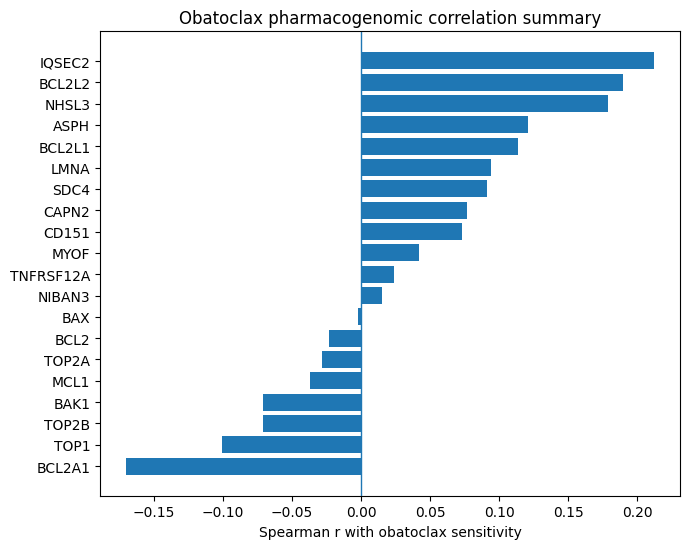

In [10]:
# ---- 5b. Plot compact gene-correlation summary ----
if len(obatoclax_summary):
    plot_df = obatoclax_summary.copy()
    plot_df = plot_df.sort_values("Spearman r")
    fig, ax = plt.subplots(figsize=(7, max(4, 0.28 * len(plot_df))))
    ax.barh(plot_df["Gene"], plot_df["Spearman r"])
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Spearman r with obatoclax sensitivity")
    ax.set_title("Obatoclax pharmacogenomic correlation summary")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "obatoclax_gene_correlation_summary.png", dpi=200)
    plt.show()


## 6. Generate Brian clarification table

These are the exact missing pieces that block strong interpretation.


In [11]:
# ---- 6. Clarification checklist for Brian/Robert ----
clarifications = pd.DataFrame([
    {"item":"H11", "question":"What is the chemical identity of H11? Does it map to a BW-II ID?", "priority":"High"},
    {"item":"D12", "question":"What is the chemical identity of D12? Does it map to a BW-II ID?", "priority":"High"},
    {"item":"2H11", "question":"What is the chemical identity of 2H11? Is it a repeat, derivative, or plate label?", "priority":"High"},
    {"item":"BW1", "question":"What compound does BW1 refer to in the older CCK-8 files?", "priority":"High"},
    {"item":"BW-II-71 / BW-II-103", "question":"Confirm BW-II-71 and BW-II-103 are the same compound and which ID should be primary.", "priority":"Medium"},
    {"item":"Vehicle/control", "question":"Confirm vehicle, blank wells, and normalization convention for each CCK-8 sheet.", "priority":"High"},
    {"item":"Cell lines", "question":"Confirm which sheets correspond to LLC, LLC-RR, MOC-2, SCCVII, or other cell lines.", "priority":"High"},
    {"item":"Final compounds 6 and 10", "question":"Confirm whether compounds 6 and 10 are synthesized, in progress, or proposed only.", "priority":"High"},
])
clarifications.to_csv(OUTPUT_DIR / "brian_clarification_questions.csv", index=False)
clarifications


,item,question,priority
0,H11,What is the chemical identity of H11? Does it ...,High
1,D12,What is the chemical identity of D12? Does it ...,High
2,2H11,What is the chemical identity of 2H11? Is it a...,High
3,BW1,What compound does BW1 refer to in the older C...,High
4,BW-II-71 / BW-II-103,Confirm BW-II-71 and BW-II-103 are the same co...,Medium
5,Vehicle/control,"Confirm vehicle, blank wells, and normalizatio...",High
6,Cell lines,"Confirm which sheets correspond to LLC, LLC-RR...",High
7,Final compounds 6 and 10,Confirm whether compounds 6 and 10 are synthes...,High


## 7. Notebook completion check

Run this cell at the end. It reports file counts and flags records needing manual review.


In [12]:
# ---- 7. Completion summary ----
print("Outputs written to:", OUTPUT_DIR.resolve())
print("Figures written to:", FIG_DIR.resolve())
print()
print("Compound records:", len(compound_manifest))
print("SMILES valid:", compound_manifest.get("smiles_valid", pd.Series(dtype=bool)).sum() if "smiles_valid" in compound_manifest else "not checked")
print("Compound records needing manual review:", compound_manifest["needs_manual_review"].sum() if "needs_manual_review" in compound_manifest else "NA")
print()
print("Raw well records:", len(raw_all))
print("Summary activity records:", len(summary_all))
print("EC50 rows:", len(ec50_summary))
print()
print("Files created:")
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(" -", p.name)
print("\nFigure count:", len(list(FIG_DIR.glob("*.png"))))


Outputs written to: /mnt/data/notebook_test/outputs
Figures written to: /mnt/data/notebook_test/outputs/figures

Compound records: 13
SMILES valid: 13
Compound records needing manual review: 7

Raw well records: 2592
Summary activity records: 72
EC50 rows: 12

Files created:
 - brian_clarification_questions.csv
 - cck8_raw_well_values.csv
 - cck8_summary_tidy.csv
 - compound_manifest_clean.csv
 - ec50_summary.csv
 - public_obatoclax_gene_summary.csv

Figure count: 13
